# 03b — ระบบท่อและการไหลของสารละลาย (Hydraulic network)

**เป้าหมาย**: ใส่ท่อน้ำลงใน twin — ท่อสีฟ้า (จ่ายสารละลาย), ราง/ถาดปลูก, ท่อสีขาว (น้ำกลับ/drain และน้ำประปาจากก๊อก) — แล้วแสดง **ทิศทางการไหล** แบบแอนิเมชันบนโมเดล 3 มิติ

ที่มา
- **ท่อสีฟ้า**: สกัดจาก point cloud ด้วยสี (~8.9k จุด) → เห็นท่อบนพื้นทางเดิน Y≈2.2, ท่อยืนที่ปลาย rack X≈6.15 พร้อมสามทางทุกชั้น, ท่อแยกลงถังใต้ชั้น 1
- **ท่อฟ้าบนพื้น = ท่อรวม drain/ล้นระหว่างถัง ไม่ใช่ท่อจ่าย** (แก้ 14 ก.ย.): ต่อกับก้นถังทั้ง 3 ใบผ่านยูเนียน+วาล์วเขียว และทะลุผนังไปทิ้งข้างนอก; **ท่อจ่าย growing คือท่อขาว 1" ที่ออกจากข้างถัง 200 L (bulkhead, ภาพ 2535) วิ่งตามหน้า rack ที่ระดับ ~0.3 ม.** ไปโคนท่อยืนขาวด้านประตู
- **ท่อสีขาว**: จากภาพถ่าย IMG_2555–2573 เท่านั้น — ⚠️ **โครง rack เป็นท่อ PVC สีครีม/ขาวเหมือนกัน** จึงแยกด้วยสีจาก point cloud ไม่ได้
- **ป้ายวาล์วบนผนัง X=L (IMG_2566)**: ซ้าย "น้ำประปา", ขวา "น้ำ RO" → ท่อขาวคู่บนพื้นทางเดินคือ **น้ำเติม 2 ชนิด** (ประปา / RO)
- **ยืนยันหน้างาน 14 ก.ย. (ตรงกับแปลนหน้า 6–7)**: ท่อขาวด้านประตู (ภาพ 2569–2573) = **"ท่อน้ำเวียนขาเข้า" growing stage** พร้อมวาล์วปรับสมดุล; ท่อยืนฟ้าปลาย rack (ภาพ 2561–2564) = **"ท่อน้ำเวียนลงถัง"** 200 L → น้ำในถาดไหล **ประตู → ปลายห้อง**
- **วงจรอนุบาล**: ถังอนุบาลแต่ละใบมีปั๊มของตัวเองตามแปลน (สายขึ้นถาดยังไม่มีภาพ → เส้นประ); หัวจ่ายอนุบาล 1 = หัวท่อขาว + วาล์วแดง 3 ตัว (2569); ถาดระบายจากก้นถาดลงท่อฟ้าตั้ง → วาล์วเขียว "ก๊อกน้ำวนถัง" → ถังของตัวเอง (2558/2565); ถังต่อท่อรวมพื้นด้วยยูเนียน+วาล์วเขียว (ถ่ายน้ำ/ล้น)
- โครงข่ายอยู่ใน `pfal_twin/hydraulics.py` (`build_network`) เป็น polyline ในพิกัดห้อง แต่ละเส้นมี `kind` (supply / supply_hdr / tray / return / return_hyp / drain / fill_tap / fill_ro), `loop` (gc1 = growing ชั้น 2–5 ถัง 200 L, gc2 = อนุบาล 2, n1 = อนุบาล 1 ไม่มีตัวควบคุม), เส้นผ่านศูนย์กลาง, และหลักฐาน

> ข้อจำกัด: **ไม่มีเซ็นเซอร์อัตราการไหล** — แอนิเมชันแสดงทิศทางและสถานะปั๊ม (`pwmWater` จาก ThingsBoard) เท่านั้น ความเร็วเป็นภาพแทน; ท่อใต้ถาด/ในถังที่มองไม่เห็นวาดตามหลักไฮดรอลิก

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from pfal_twin import io, geometry as G, viz, layout, thingsboard as tb, hydraulics as H, schematic as S
pio.renderers.default = "vscode+notebook"   # works in VS Code and JupyterLab
FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
print("project root:", ROOT)

project root: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL


## 1. โหลดโมเดล + point cloud และสกัดจุดท่อสีฟ้า

In [2]:
model = io.load_model(); zones = io.load_model("zones.json")["zones"]
sensors, eq = layout.load_layout()
pc = io.load_clean(); P, RGB = pc["xyz"], pc["rgb"]; R, K = model["room"], model["rack"]
blue = H.blue_pvc_mask(P, RGB)
print(f"blue PVC points: {blue.sum():,}")

blue PVC points: 8,858


## 2. โครงข่ายท่อ (hand-modelled) — ตารางเส้นท่อ

In [3]:
net = H.build_network(model, zones)
H.save_network(net)
tab = H.edges_table(net)
print(f"{len(tab)} edges, total {tab.length_m.sum():.1f} m"); display(tab.groupby(["kind", "loop"]).length_m.sum().round(1).to_frame("length m"))
tab[["name", "kind", "loop", "dia_mm", "length_m", "evidence"]]

42 edges, total 73.7 m


length m
kind       loop            
dosing     gc1          0.5
           gc2          0.4
drain      shared       2.6
fill_ro    gc2          0.3
           n1           0.3
           shared      10.2
fill_tap   shared       9.3
manifold   shared       7.2
return     gc1          4.5
           gc2          0.2
           n1           0.4
return_hyp n1           1.0
supply     gc1          6.5
           gc2          0.2
supply_hdr gc1          4.2
           gc2          0.3
           n1           1.0
tray       gc1         21.2
           gc2          2.2
           n1           1.3

,name,kind,loop,dia_mm,length_m,evidence
0,"200 L tank bottom outlet (union, green valve) ...",manifold,shared,48,1.05,"IMG_2559/2567/2544: blue 1.5"" pipe out of the ..."
1,tee -> floor manifold,manifold,shared,48,0.10,IMG_2559
2,waste drain -> through the X=L wall to outside,drain,shared,48,1.32,IMG_2559 + scan: blue elbow at the wall corner...
3,floor manifold along the aisle (far end -> doo...,manifold,shared,48,4.55,"IMG_2555/2568 + scan: blue 1.5"" line on the fl..."
4,"200 L tank pump -> white 1"" pipe through the l...",supply,gc1,25,0.84,"IMG_2585: white 1"" pipe across the 200 L tank ..."
5,"white 1"" line along the rack (~0.3 m high) -> ...",supply,gc1,25,5.63,IMG_2555/2568/2584: white line at ~0.3 m on th...
6,white 0.3 m line -> red valve -> nursery-2 tra...,supply_hdr,gc2,25,0.33,IMG_2584: white pipe rises from the 0.3 m line...
7,white supply riser (door end),supply_hdr,gc1,25,1.77,IMG_2570 (confirmed 2026-09-14 = growing-stage...
8,tier 2 supply header + balancing valves -> tra...,supply_hdr,gc1,25,0.60,"IMG_2570-2573 (confirmed 2026-09-14): white 1""..."
9,tray 2 (door -> far),tray,gc1,48,5.30,


## 3. ตรวจสอบกับ point cloud — จุดสีฟ้าจากสแกน ซ้อนเส้นท่อของโมเดล (plan + elevation)

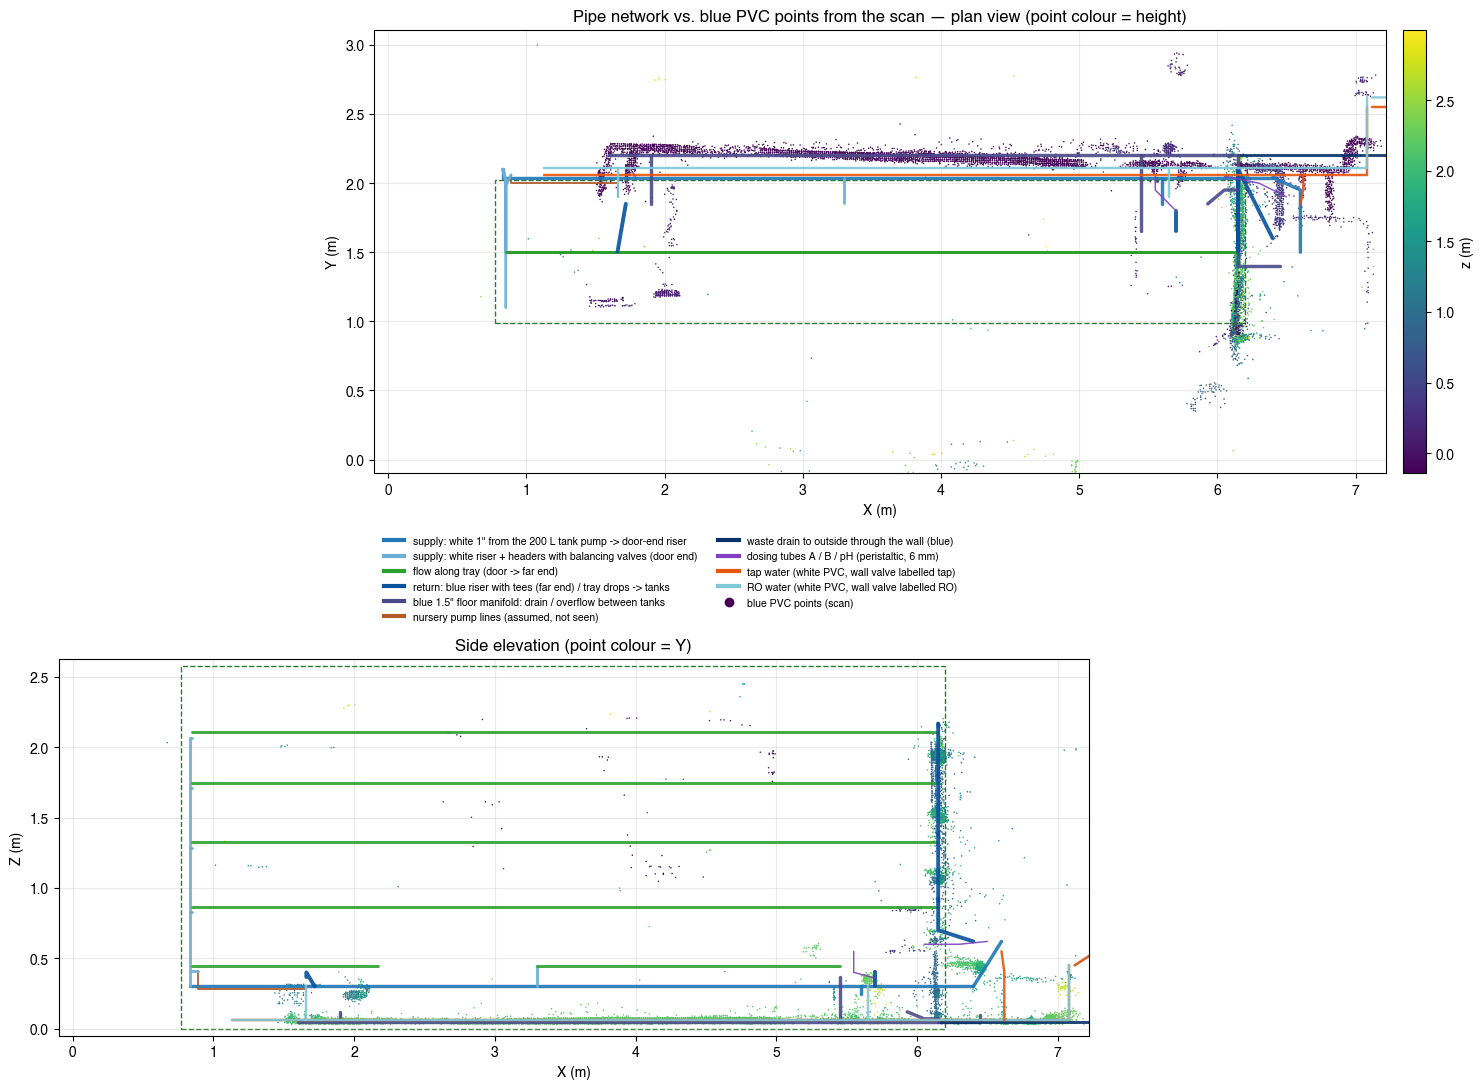

In [4]:
from matplotlib.lines import Line2D
fig, axes = plt.subplots(2, 1, figsize=(18, 11), gridspec_kw=dict(height_ratios=[1, 0.85]))
for ax, (i, j, lab) in zip(axes, [(0, 1, "Y (m)"), (0, 2, "Z (m)")]):
    sc = ax.scatter(P[blue, i], P[blue, j], s=1.2, c=P[blue, 2 if j == 1 else 1], cmap="viridis", linewidths=0)
    for e in net["edges"]:
        q = np.array(e["pts"]); st = H.KIND_STYLE[e["kind"]]
        ax.plot(q[:, i], q[:, j], color=st["color"], lw=st["width"] * 0.35, alpha=0.9, solid_capstyle="round")
    ax.add_patch(plt.Rectangle((K["x0"], K["y0"] if j == 1 else 0), K["length"], K["width"] if j == 1 else K["top_frame_z"], fill=False, ec="#2a7d2a", ls="--", lw=1))
    ax.set_aspect("equal"); ax.set_xlim(-0.1, R["L"] + 0.1); ax.set_xlabel("X (m)"); ax.set_ylabel(lab); ax.grid(alpha=.25)
axes[0].set_ylim(-0.1, R["W"] + 0.1); axes[1].set_ylim(-0.05, R["H"] + 0.05)
axes[0].set_title("Pipe network vs. blue PVC points from the scan — plan view (point colour = height)")
axes[1].set_title("Side elevation (point colour = Y)")
axes[0].legend(handles=[Line2D([0], [0], color=v["color"], lw=3, label=v["name"]) for v in H.KIND_STYLE.values()] + [Line2D([0], [0], marker="o", ls="", color="#440154", label="blue PVC points (scan)")],
               fontsize=7.5, loc="upper left", bbox_to_anchor=(0, -0.12), ncol=2, frameon=False)
plt.colorbar(sc, ax=axes[0], fraction=0.02, pad=0.01, label="z (m)")
fig.tight_layout(); fig.savefig(FIG / "03b_pipes_vs_scan.png", dpi=150)

เส้นสีฟ้าของโมเดลควรทับกลุ่มจุดสแกน (ท่อเมนบนพื้น, ท่อยืน, ท่อแยกลงถัง) — เส้นสีขาว/เขียวไม่มีจุดสแกนให้เทียบ เพราะแยกสีไม่ได้และรางถูกบัง

### 3b. รายละเอียดมุมถังปลายห้อง (เทียบภาพ IMG_2559 / 2567) — ท่อทุกเส้น + ข้อต่อ/วาล์ว

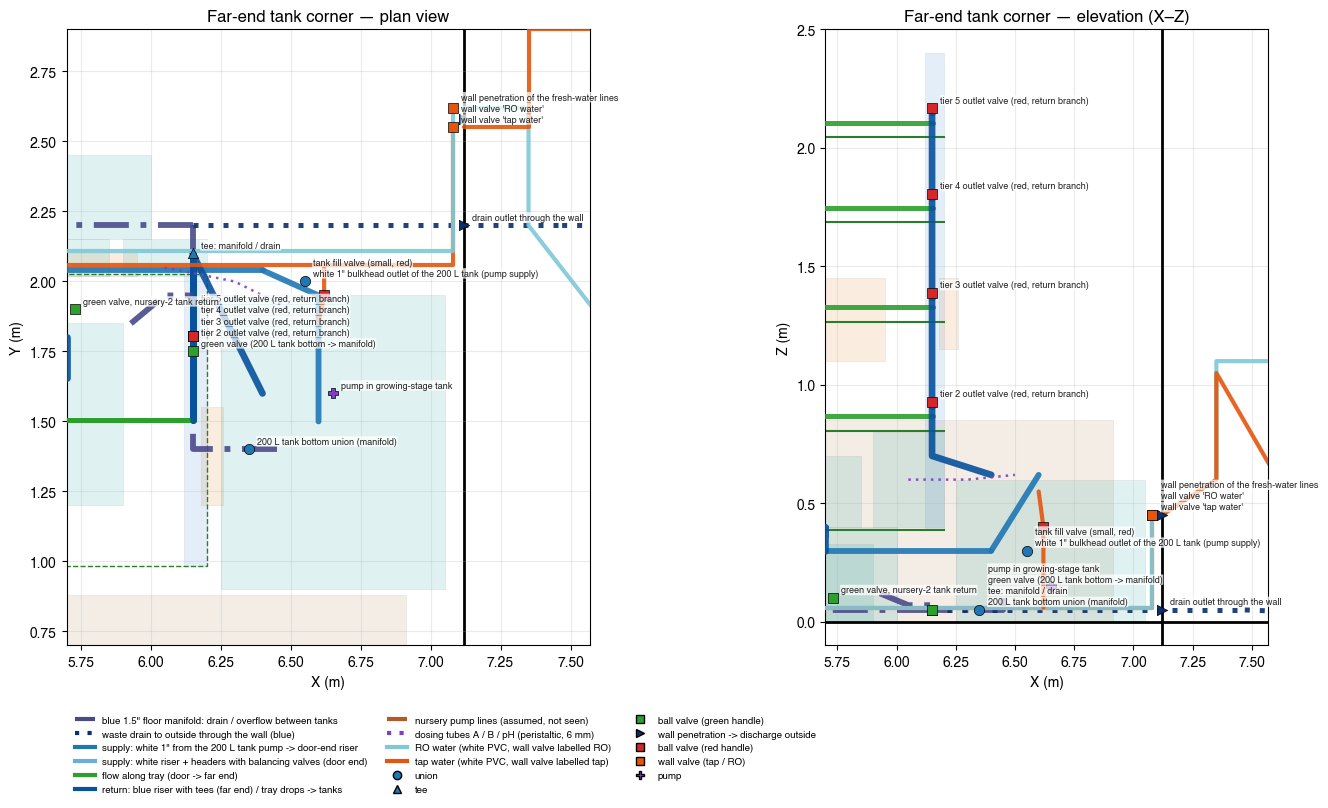

In [5]:
fig = viz.pipe_corner_detail(model, net, eq[eq.location == "inside"])
fig.savefig(FIG / "03b_tank_corner_detail.png", dpi=150, bbox_inches="tight")

ลำดับตามภาพ 2559 + แปลน: ถัง (ปั๊ม) → ยูเนียน → สามทาง → ท่อเมนบนพื้นไปด้านประตู (จ่าย) / ท่อระบายทิ้งทะลุผนัง X=L ออกนอกห้อง (เห็นท่อฟ้าบนพื้นข้างนอกในภาพ 2553); ท่อยืนฟ้าที่มุมนี้คือ**น้ำกลับ**จากถาดทุกชั้นลงถัง; ท่อขาวประปา/RO จากวาล์วผนัง เส้นหนึ่งแยกผ่านวาล์วแดงเล็กเข้าถัง; ท่อขาวประปา/RO จากวาล์วบนผนังวิ่งตามพื้น เส้นหนึ่งแยกผ่านวาล์วแดงเล็กเข้าถัง

## 4. ภาพ 3 มิติ + แอนิเมชันการไหล (กด ▶ Play; ใช้ปุ่ม Full screen หรือเปิดไฟล์ html)

In [6]:
base = viz.model_traces(model, tier_color="#dddddd") + viz.equipment_traces(eq[eq.location == "inside"], opacity=0.15)
fig3d = H.flow_figure(net, base, n_frames=24, spacing=0.25, title="Nutrient-solution flow — schematic direction (no flow sensor)")
viz.show3d(fig3d, "03b_flow_animation", height=820)

full-window version: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/figures/html/03b_flow_animation.html   (open in a browser)


PosixPath('/Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/figures/html/03b_flow_animation.html')

## 4b. ระบบน้ำภายนอกห้อง — ภาพ IMG_2577–2579 + แปลนสไลด์ 3 ("ตำแหน่งและเส้นทางท่อน้ำดีและน้ำทิ้ง")
- **ทางเดินบริการข้างอาคาร**: ถังเก็บน้ำ RO (ถังสลิมสีเทา, แปลน 5 m³) → ปั๊มหอยโข่ง (สีเหลือง, แปลน ≥3000 L/h) → ชุดกรอง RO 3 ขั้น → ท่อฟ้า 2 เส้นวิ่งตามผนังคอนเทนเนอร์ → ทะลุผนังปลายห้องที่วาล์ว "น้ำประปา" / "น้ำ RO"
- **ท่อน้ำทิ้ง**: ท่อฟ้าออกจากผนังปลายห้องระดับพื้น วิ่งตามพื้นด้านนอก → ตามแปลนไป**ถังเก็บสารละลายใช้แล้วฝังใต้ดิน** (ยังไม่เห็นถัง)
- ตำแหน่งภายนอกในโมเดลเป็น **schematic** (ไม่ได้สแกน)

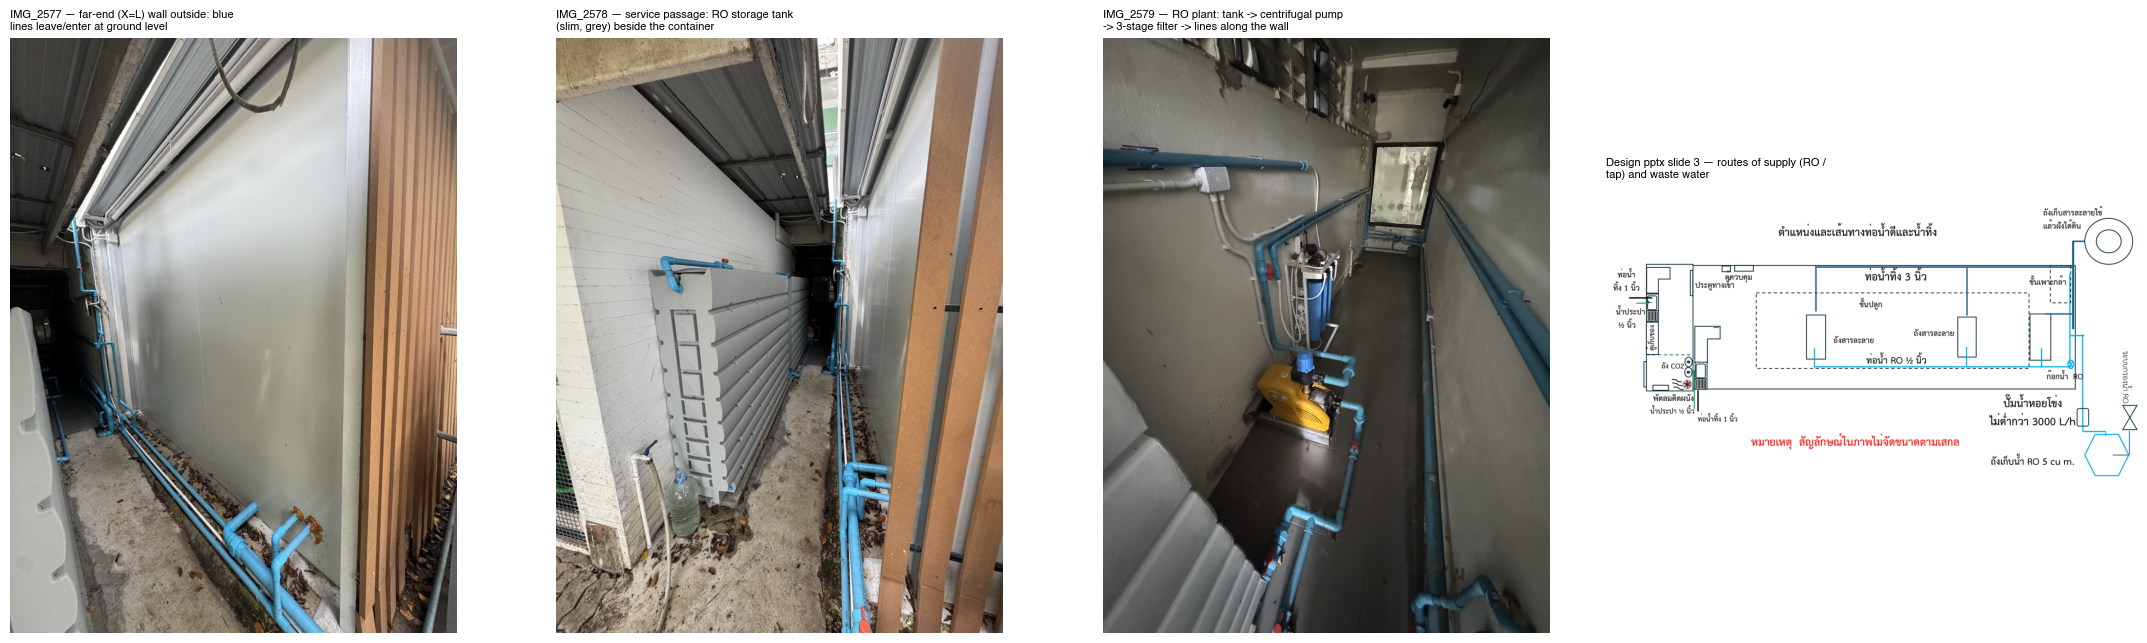

In [7]:
from PIL import Image, ImageOps
import textwrap
fig, axes = plt.subplots(1, 4, figsize=(22, 6.5))
for ax, (f, cap) in zip(axes, [("picture/jpg/IMG_2577.jpg", "IMG_2577 — far-end (X=L) wall outside: blue lines leave/enter at ground level"),
                               ("picture/jpg/IMG_2578.jpg", "IMG_2578 — service passage: RO storage tank (slim, grey) beside the container"),
                               ("picture/jpg/IMG_2579.jpg", "IMG_2579 — RO plant: tank -> centrifugal pump -> 3-stage filter -> lines along the wall"),
                               ("doc/../../../docs/plan_drawing/slide-3.png", "Design pptx slide 3 — routes of supply (RO / tap) and waste water")]):
    pth = io.RAW / f
    ax.imshow(ImageOps.exif_transpose(Image.open(pth))); ax.set_title("\n".join(textwrap.wrap(cap, 46)), fontsize=8, loc="left"); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG / "03b_outside_water.png", dpi=100)

## 4c. ผังเฉพาะระบบน้ำและปุ๋ย — ถัง, ชุดจ่ายปุ๋ย, ตัวควบคุม, วาล์ว, ท่อทุกชนิด, RO plant และท่อทิ้งภายนอก

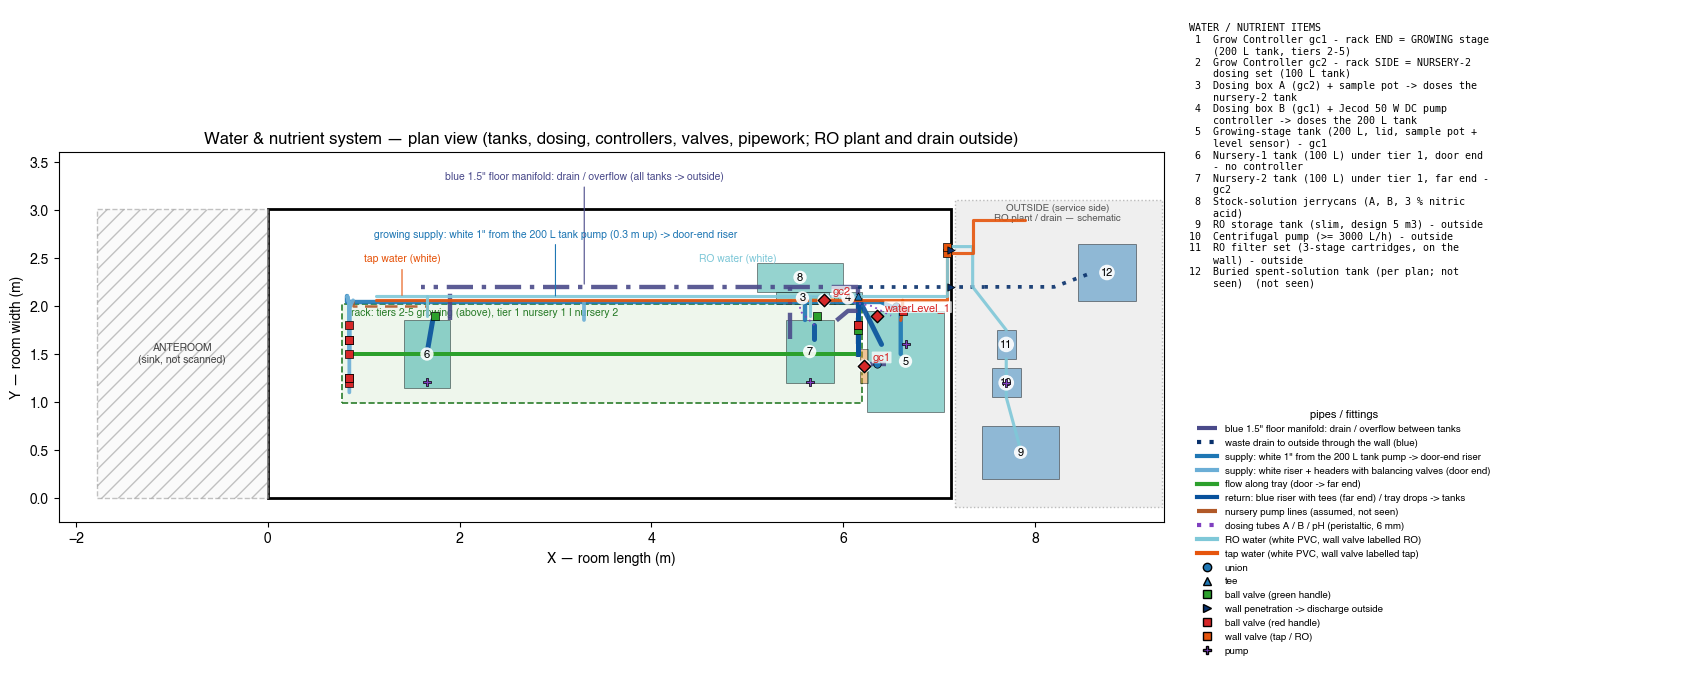

In [8]:
fig = S.water_system_plan(model, net, eq, sensors)
fig.savefig(FIG / "03b_water_system_plan.png", dpi=150, bbox_inches="tight")

## 4d. แผนภาพการไหลของระบบน้ำ (process flow, ไม่ตามสเกล) — เส้นทึบ = เห็นจริง/ยืนยัน, เส้นประ = สมมติ/ตามแปลน

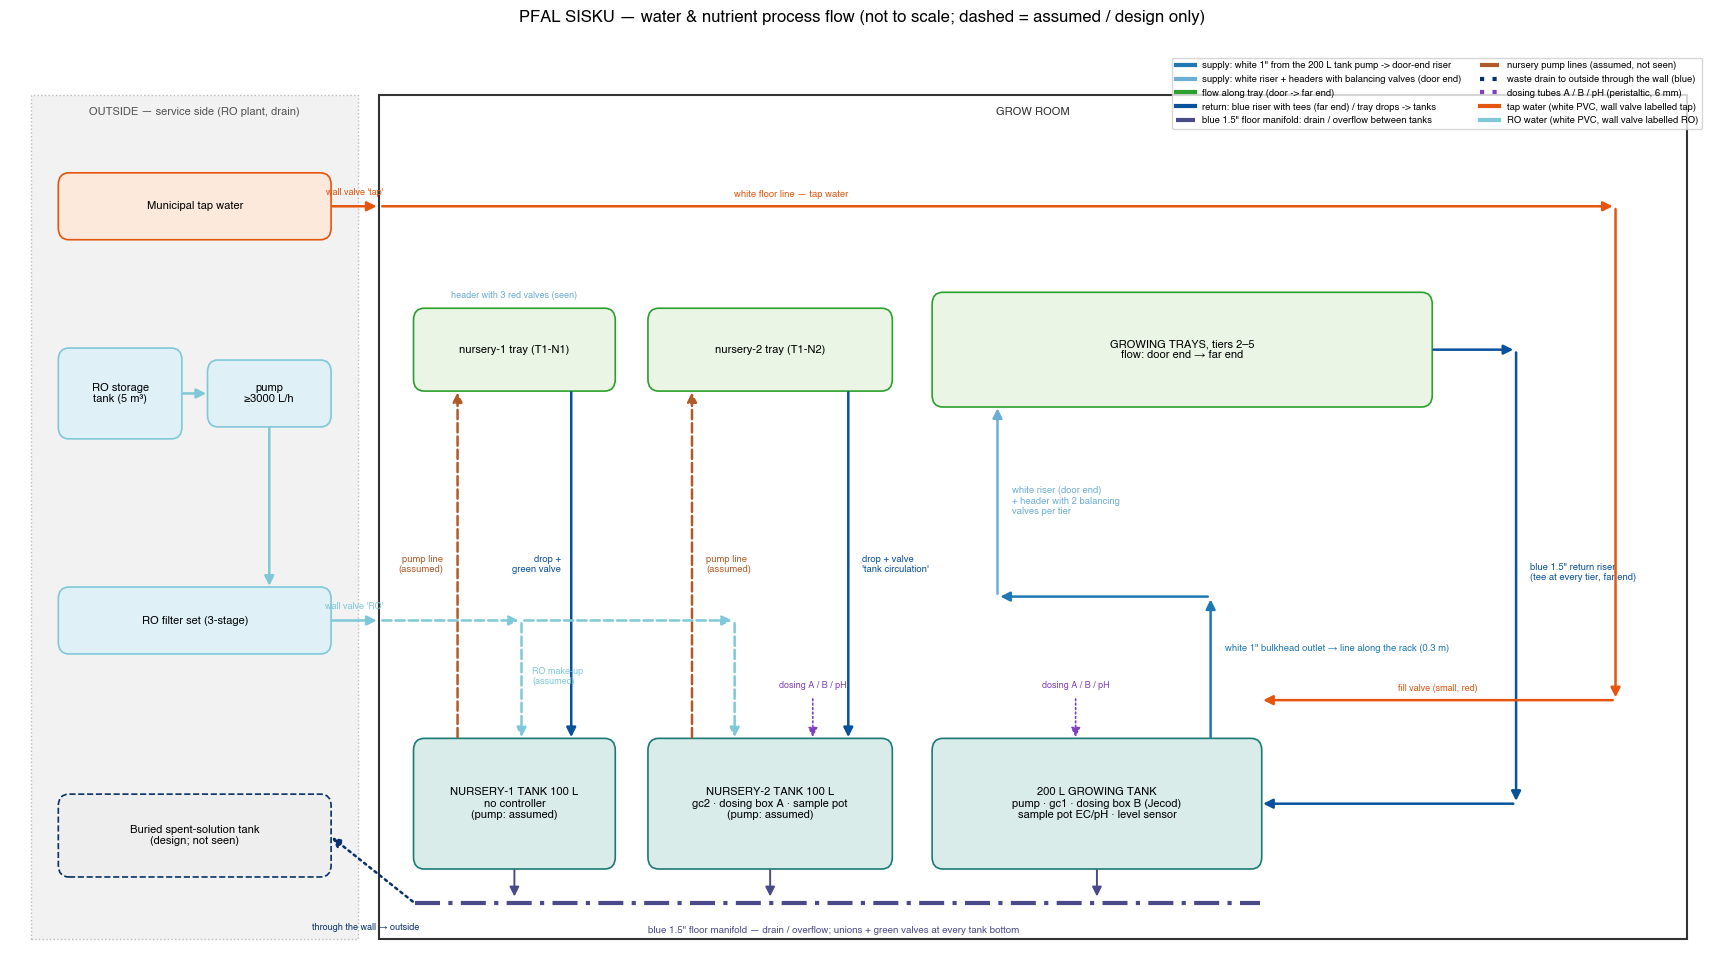

In [9]:
fig = S.water_flow_diagram()
fig.savefig(FIG / "03b_water_flow_diagram.png", dpi=150, bbox_inches="tight")

## 5. สถานะปั๊มจากข้อมูลจริง — `pwmWater` (ปั๊มหมุนเวียน) และปั๊ม dosing ของแต่ละวงจร

,on fraction,hours on,n bins
col,,,
gc1.pwmWater,0.85,1892.00,13279
gc2.pwmWater,0.69,1296.83,11221
gc1.pumpA,0.00,5.17,13279
gc1.pumpB,0.00,2.67,13279
gc1.pumpPH,0.02,54.50,13279
gc2.pumpA,0.02,28.83,11221
gc2.pumpB,0.04,75.33,11221
gc2.pumpPH,0.01,26.83,11221


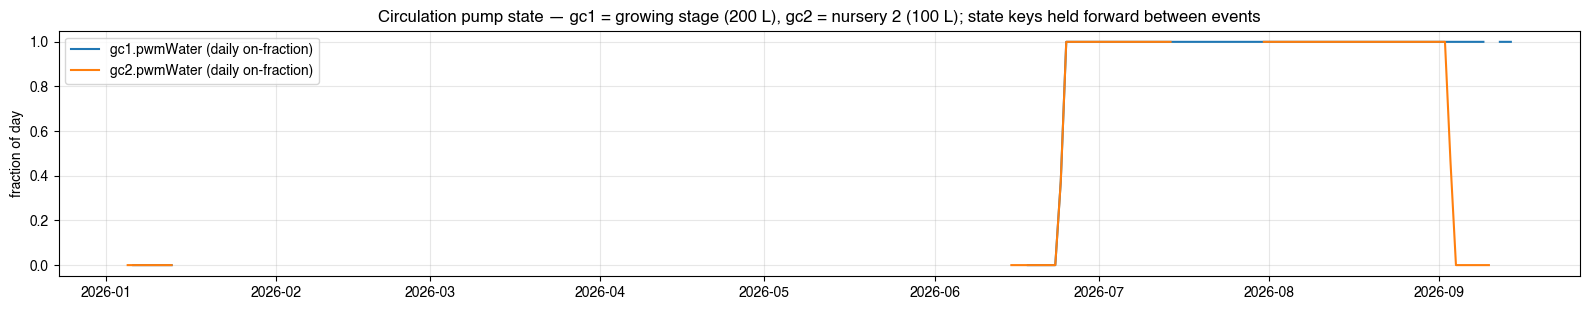

In [10]:
w = pd.read_parquet(tb.WIDE_PARQUET)
cols = [c for c in ("gc1.pwmWater", "gc2.pwmWater", "gc1.pumpA", "gc1.pumpB", "gc1.pumpPH", "gc2.pumpA", "gc2.pumpB", "gc2.pumpPH") if c in w]
st = w[cols]
duty = pd.DataFrame({"on fraction": st.mean(), "hours on": st.sum() / 6, "n bins": st.count()}).round(2); display(duty)
fig, ax = plt.subplots(figsize=(16, 3.2))
for c, col in zip(("gc1.pwmWater", "gc2.pwmWater"), ("#1f77b4", "#ff7f0e")):
    if c in st: d = st[c].resample("1D").mean(); ax.plot(d.index, d, color=col, lw=1.5, label=f"{c} (daily on-fraction)")
ax.set_ylim(-0.05, 1.05); ax.set_ylabel("fraction of day"); ax.set_title("Circulation pump state — gc1 = growing stage (200 L), gc2 = nursery 2 (100 L); state keys held forward between events"); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(FIG / "03b_pump_state.png", dpi=150)

## สรุป / สิ่งที่ยังไม่ยืนยัน
- วงจรปลูก (ชั้น 2–5): ปั๊มในถัง 200 L → **ท่อขาว 1" ออกข้างถัง วิ่งตามหน้า rack ที่ 0.3 ม.** → ท่อยืนขาวด้านประตู → หัวท่อ + วาล์วปรับสมดุล → ถาด (ประตู → ปลายห้อง) → กิ่งฟ้า + วาล์วแดง → ท่อยืนฟ้าปลายห้อง → ลงถัง — ยืนยันหน้างาน 14 ก.ย.
- ท่อฟ้า 1.5" บนพื้น = **ท่อรวม drain/ล้น** เชื่อมก้นถังทั้ง 3 ใบ (ยูเนียน + วาล์วเขียว) และทะลุผนังไปทิ้งข้างนอก; ท่อขาวบนพื้น 2 เส้น = น้ำประปา + น้ำ RO จากวาล์วที่มีป้าย
- **อนุบาล 2 (ภาพ 2558/2560/2544)**: ท่อฟ้าตั้ง 2 ท่อจากก้นถาดเหนือถัง — ท่อหนึ่งมีวาล์วเขียว "ก๊อกน้ำวนถัง" ลงถัง 100 L (ระบายกลับถัง), อีกท่อลงท่อรวมพื้น (ล้น/ถ่าย); ข้างถังมียูเนียน 2 ตัว (+วาล์วเขียว) ต่อท่อรวมพื้นไปมุมถัง 200 L; **dosing box A (14) ของ gc2 จ่ายปุ๋ยลงถังนี้** (ยืนยัน 14 ก.ย.) ส่วน dosing box B (15, Jecod) เป็นของ gc1 → ถัง 200 L
- **ทางเข้าถาดอนุบาล 2 (ภาพ 2584/2585/2535)**: ท่อขาว 1" ระดับ 0.3 ม. ตามหน้า rack ยกขึ้นผ่านวาล์วแดงเข้าหัวถาดที่ X≈3.3; ท่อขาวเส้นนี้ต่อกับ**ปั๊มถัง 200 L (ท่อผ่านฝาถัง, 2585)** และ **bulkhead ข้างถังอนุบาล 2 (2535)** และวิ่งต่อไปถึงท่อยืน growing ด้านประตู → ⚠️ ยังไม่รู้ว่าปั๊มถังไหนจ่ายกิ่งไหน
- **ยังไม่ยืนยัน (เส้นประ)**: สายจากปั๊มถังอนุบาล 1 ขึ้นหัวจ่าย
- ถ้าต้องการอัตราการไหลจริง: วัดด้วยถ้วยตวงที่ปลายรางแต่ละชั้น (L/min) แล้วใส่ใน `pipe_network.json` หรือติด flow meter บนท่อเมนสีฟ้า

**ถัดไป**: notebook 05 แสดงท่อพร้อมสถานะปั๊ม ณ เวลาที่เลือกบน time slider